# Geographic-Scale Dataset Analysis

Pilot analysis of the place-based dataset assembled by `dataset_build.ipynb`. Mirrors TinyChirp Fig. 2:

- example log-mel spectrograms per target species;
- **average STFT** of all target clips vs. average STFT of the "average bird" pool (non-target other birds);
- per-species average STFT, and the per-species difference vs. the average bird — what makes each target visually distinct.

Everything is driven by `datasets/<collection>/dataset.json` — no BirdNET / XC calls here.

In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pyrootutils
import soundfile as sf
from tqdm.auto import tqdm

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

# Parameters

`COLLECTION` is the slug emitted by `dataset_build.ipynb`. The spectrogram parameters match `building/utils/constants.py` (16 kHz, 3 s clips, 1024-pt Hann STFT with 256-sample hop, 80 mel bins, 80–8000 Hz), so what we plot here matches what the models see.

In [45]:
from building.geographic_scale import load_dataset_info

COLLECTION = "paris_10"
MAX_CLIPS_PER_GROUP = 400  # cap per-species / per-pool to keep averaging tractable
RNG = np.random.default_rng(42)

info = load_dataset_info(COLLECTION)
print(
    f"{info.collection}  |  {info.place.name} "
    f"({info.place.lat:.4f}, {info.place.lon:.4f}) r={info.place.radius_km} km  |  "
    f"{info.audio.sample_rate} Hz, {info.audio.clip_duration_s:g} s  |  "
    f"{len(info.target_species)} targets / {len(info.other_species)} other birds"
)

paris_10  |  Paris (48.8566, 2.3522) r=50.0 km  |  16000 Hz, 3 s  |  10 targets / 31 other birds


# Helpers

In [46]:
from building.data.dataset import SUBSAMPLES_DIR
from building.utils.constants import (
    SAMPLE_RATE,
    TARGET_AUDIO_LEN,
    FRAME_LENGTH,
    FRAME_STEP,
    NUM_MEL_BINS_MEL,
    LOWER_EDGE_HERTZ,
    UPPER_EDGE_HERTZ,
)


def species_folder(name: str) -> Path:
    return SUBSAMPLES_DIR / name.replace(" ", "_")


def list_clips(name: str) -> list[Path]:
    folder = species_folder(name)
    return sorted(folder.glob("*.wav")) if folder.exists() else []


def load_clip(path: Path) -> np.ndarray:
    x, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if x.ndim > 1:
        x = x.mean(axis=-1)
    if sr != SAMPLE_RATE:
        # subsamples are already 16 kHz; guard just in case
        n_new = int(round(len(x) * SAMPLE_RATE / sr))
        x = np.interp(np.linspace(0, len(x), n_new, endpoint=False), np.arange(len(x)), x).astype(np.float32)
    if len(x) >= TARGET_AUDIO_LEN:
        return x[:TARGET_AUDIO_LEN]
    pad = np.zeros(TARGET_AUDIO_LEN - len(x), dtype=np.float32)
    return np.concatenate([x, pad])


window = np.hanning(FRAME_LENGTH).astype(np.float32)
n_frames = 1 + (TARGET_AUDIO_LEN - FRAME_LENGTH) // FRAME_STEP
n_freqs = FRAME_LENGTH // 2 + 1
stft_freqs = np.fft.rfftfreq(FRAME_LENGTH, d=1.0 / SAMPLE_RATE)
stft_times = (np.arange(n_frames) * FRAME_STEP + FRAME_LENGTH / 2) / SAMPLE_RATE


def stft_mag(x: np.ndarray) -> np.ndarray:
    """Magnitude STFT, shape (n_freqs, n_frames)."""
    frames = np.lib.stride_tricks.sliding_window_view(x, FRAME_LENGTH)[::FRAME_STEP]
    frames = frames * window
    return np.abs(np.fft.rfft(frames, axis=-1)).T.astype(np.float32)


def to_db(mag: np.ndarray, ref: float | None = None) -> np.ndarray:
    ref = float(mag.max()) if ref is None else ref
    return 20.0 * np.log10(np.maximum(mag, 1e-10) / max(ref, 1e-10))


def mel_filterbank(n_mels: int, n_freqs: int, sr: int, fmin: float, fmax: float) -> np.ndarray:
    def hz_to_mel(f):
        return 2595.0 * np.log10(1.0 + f / 700.0)

    def mel_to_hz(m):
        return 700.0 * (10.0 ** (m / 2595.0) - 1.0)

    mels = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hzs = mel_to_hz(mels)
    bins = np.fft.rfftfreq(FRAME_LENGTH, d=1.0 / sr)
    fb = np.zeros((n_mels, n_freqs), dtype=np.float32)
    for i in range(n_mels):
        l, c, r = hzs[i], hzs[i + 1], hzs[i + 2]
        fb[i] = np.maximum(0, np.minimum((bins - l) / (c - l + 1e-12), (r - bins) / (r - c + 1e-12)))
    return fb


mel_fb = mel_filterbank(NUM_MEL_BINS_MEL, n_freqs, SAMPLE_RATE, LOWER_EDGE_HERTZ, UPPER_EDGE_HERTZ)
mel_freqs = np.linspace(LOWER_EDGE_HERTZ, UPPER_EDGE_HERTZ, NUM_MEL_BINS_MEL)


def logmel(x: np.ndarray) -> np.ndarray:
    mag = stft_mag(x)
    mel = mel_fb @ mag
    return np.log(np.maximum(mel, 1e-6))


def avg_stft(files: list[Path], cap: int | None = None) -> tuple[np.ndarray, int]:
    if cap is not None and len(files) > cap:
        idx = RNG.choice(len(files), size=cap, replace=False)
        files = [files[i] for i in idx]
    acc = np.zeros((n_freqs, n_frames), dtype=np.float64)
    n = 0
    for f in tqdm(files, desc=f"avg-stft ({len(files)})", leave=False):
        try:
            acc += stft_mag(load_clip(f))
            n += 1
        except Exception:
            pass
    return (acc / max(n, 1)).astype(np.float32), n


def safe(sp: str) -> str:
    """Species name as a valid npz key (no spaces)."""
    return sp.replace(" ", "_")

# Clip counts

Per-species clip totals on disk. Targets are also broken down by source (XenoCanto vs Macaulay/eBird) — the filename prefix (`XC…`, `ML…`) is the source tag. Other-bird stats (min / max / mean / total) tell us how lopsided the `non_target` pool is before the per-species cap kicks in.

In [47]:
import re

import pandas as pd

XC_RE = re.compile(r"(?:^|__)XC\d+_")
ML_RE = re.compile(r"(?:^|__)ML\d+_")


def count_by_source(clips: list[Path]) -> tuple[int, int, int]:
    xc = sum(1 for p in clips if XC_RE.search(p.name))
    ml = sum(1 for p in clips if ML_RE.search(p.name))
    return len(clips), xc, ml


target_rows = []
for sp in info.target_species:
    n, n_xc, n_ml = count_by_source(list_clips(sp))
    target_rows.append(
        {"species": sp, "total": n, "xc": n_xc, "ebird": n_ml, "other": n - n_xc - n_ml}
    )
target_df = pd.DataFrame(target_rows)
target_df.loc["TOTAL"] = {
    "species": f"{len(target_df)} target species",
    "total": target_df["total"].sum(),
    "xc": target_df["xc"].sum(),
    "ebird": target_df["ebird"].sum(),
    "other": target_df["other"].sum(),
}
display(target_df)

# "other birds" stats: raw on-disk counts can be inflated when a species
# was downloaded heavily for another collection (top-N elsewhere → kept on
# disk → reused here as non-target). The per-species cap in
# `balanced_non_target` is applied per provider (XC + eBird), so the
# effective max per species is 2 * cap. Anything beyond that is leftover
# from another collection and gets dropped on assembly.
cap = 2 * info.budgets.non_target_per_species_cap
other_counts = [len(list_clips(sp)) for sp in info.other_species]
other_counts_nz = [n for n in other_counts if n > 0]
capped_nz = [min(n, cap) for n in other_counts_nz]


def stats(values: list[int]) -> dict:
    return {
        "min": min(values) if values else 0,
        "max": max(values) if values else 0,
        "mean": round(sum(values) / len(values), 1) if values else 0,
        "total": sum(values),
    }


other_stats = pd.DataFrame(
    [
        {"species_with_clips": f"{len(other_counts_nz)} / {len(info.other_species)}", **stats(other_counts_nz)},
        {"species_with_clips": f"capped at {cap}/species (2 × {cap // 2})", **stats(capped_nz)},
    ],
    index=["other birds (raw)", "other birds (post-cap)"],
)
display(other_stats)

,species,total,xc,ebird,other
0,Anthus spinoletta,2375,1310,1065,0
1,Parus major,10000,5000,5000,0
2,Psittacula krameri,5636,1621,4015,0
3,Hippolais polyglotta,10000,5000,5000,0
4,Dendrocoptes medius,4870,2404,2466,0
5,Fringilla coelebs,10000,5000,5000,0
6,Certhia brachydactyla,8705,3276,5429,0
7,Curruca communis,3510,1859,1651,0
8,Troglodytes troglodytes,600,300,300,0
9,Erithacus rubecula,600,300,300,0


,species_with_clips,min,max,mean,total
other birds (raw),26 / 31,231,9897,930.3,24189
other birds (post-cap),capped at 600/species (2 × 300),231,600,572.8,14892


# Average STFT: targets vs "average bird" (TinyChirp Fig. 2)

Top panel: average magnitude STFT over all target-species clips (pooled). Bottom panel: average over non-target other-bird clips — this is the "average bird" the targets are competing against in `non_target`. A frequency band that lights up on top but not on bottom is a band the model can lean on.

Cached to `datasets/<collection>/analysis_cache.npz` so re-runs are instant.

In [48]:
from building.geographic_scale import info_path

cache_path = info_path(COLLECTION).parent / "analysis_cache.npz"


def gather_files(species_list: list[str]) -> list[Path]:
    out: list[Path] = []
    for sp in species_list:
        out.extend(list_clips(sp))
    return out


def compute_cache() -> dict:
    payload: dict[str, np.ndarray] = {}
    target_files = gather_files(info.target_species)
    other_files = gather_files(info.other_species)
    print(f"target pool : {len(target_files)} clips")
    print(f"other pool  : {len(other_files)} clips")
    avg_t, n_t = avg_stft(target_files, cap=MAX_CLIPS_PER_GROUP * len(info.target_species))
    avg_o, n_o = avg_stft(other_files, cap=MAX_CLIPS_PER_GROUP * max(1, len(info.other_species)))
    payload["avg_target"] = avg_t
    payload["avg_other"] = avg_o
    payload["n_target"] = np.array(n_t)
    payload["n_other"] = np.array(n_o)
    for sp in info.target_species:
        files = list_clips(sp)
        if not files:
            continue
        avg_sp, n_sp = avg_stft(files, cap=MAX_CLIPS_PER_GROUP)
        payload[f"species__{safe(sp)}"] = avg_sp
        payload[f"count__{safe(sp)}"] = np.array(n_sp)
    np.savez(cache_path, **payload)
    return payload


if cache_path.exists():
    cache = dict(np.load(cache_path, allow_pickle=False))
    print(f"loaded cache: {cache_path}")
else:
    cache = compute_cache()
    print(f"wrote cache: {cache_path}")

print(f"  n_target = {int(cache['n_target'])}")
print(f"  n_other  = {int(cache['n_other'])}")

loaded cache: /home/nathan/Documents/multi-chirp/datasets/paris_10/analysis_cache.npz
  n_target = 4000
  n_other  = 12400


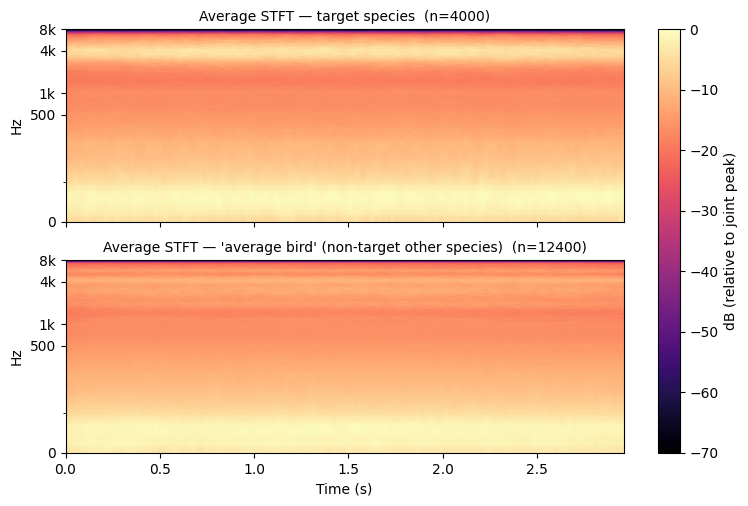

In [49]:
avg_t = cache["avg_target"]
avg_o = cache["avg_other"]
ref = float(max(avg_t.max(), avg_o.max()))

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
for ax, mag, label, n in [
    (axes[0], avg_t, "Average STFT — target species", int(cache["n_target"])),
    (axes[1], avg_o, "Average STFT — 'average bird' (non-target other species)", int(cache["n_other"])),
]:
    im = ax.imshow(
        to_db(mag, ref=ref),
        origin="lower",
        aspect="auto",
        extent=[0, stft_times[-1], stft_freqs[0], stft_freqs[-1]],
        vmin=-70,
        vmax=0,
        cmap="magma",
    )
    ax.set_yscale("symlog", linthresh=200)
    ax.set_yticks([0, 500, 1000, 4000, 8000])
    ax.set_yticklabels(["0", "500", "1k", "4k", "8k"])
    ax.set_ylabel("Hz")
    ax.set_title(f"{label}  (n={n})", fontsize=10)
axes[-1].set_xlabel("Time (s)")
fig.colorbar(im, ax=axes.ravel().tolist(), label="dB (relative to joint peak)")
plt.show()

# Per-species average STFT

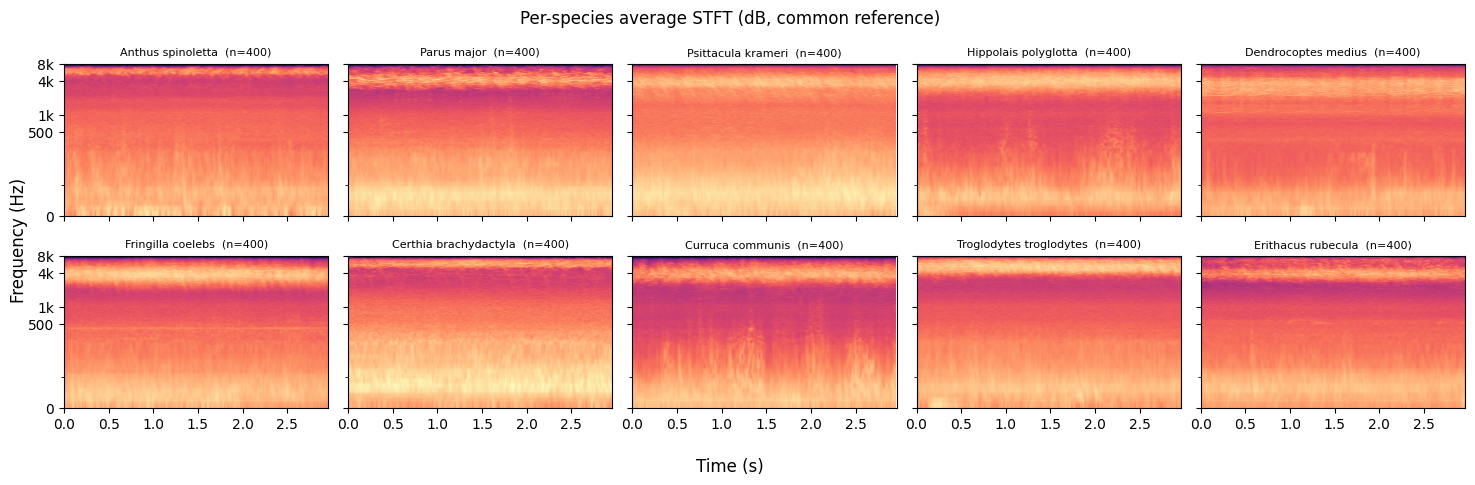

In [50]:
species = [sp for sp in info.target_species if f"species__{safe(sp)}" in cache]
n = len(species)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 2.4 * rows), squeeze=False, sharex=True, sharey=True)
ref = float(max(cache[f"species__{safe(sp)}"].max() for sp in species))
for ax, sp in zip(axes.ravel(), species):
    mag = cache[f"species__{safe(sp)}"]
    ax.imshow(
        to_db(mag, ref=ref),
        origin="lower",
        aspect="auto",
        extent=[0, stft_times[-1], stft_freqs[0], stft_freqs[-1]],
        vmin=-70,
        vmax=0,
        cmap="magma",
    )
    ax.set_yscale("symlog", linthresh=200)
    ax.set_yticks([0, 500, 1000, 4000, 8000])
    ax.set_yticklabels(["0", "500", "1k", "4k", "8k"])
    ax.set_title(f"{sp}  (n={int(cache[f'count__{safe(sp)}'])})", fontsize=8)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.supxlabel("Time (s)")
fig.supylabel("Frequency (Hz)")
fig.suptitle("Per-species average STFT (dB, common reference)")
plt.tight_layout()
plt.show()

# Per-species difference vs. the average bird

`(per-species average STFT in dB) − (non-target other-bird average STFT in dB)` — positive (red) means the species is louder than the average bird at that (frequency, time) cell, negative (blue) means quieter. Each species is dB-normalised to its own peak before the subtraction so we compare *shape*, not loudness.

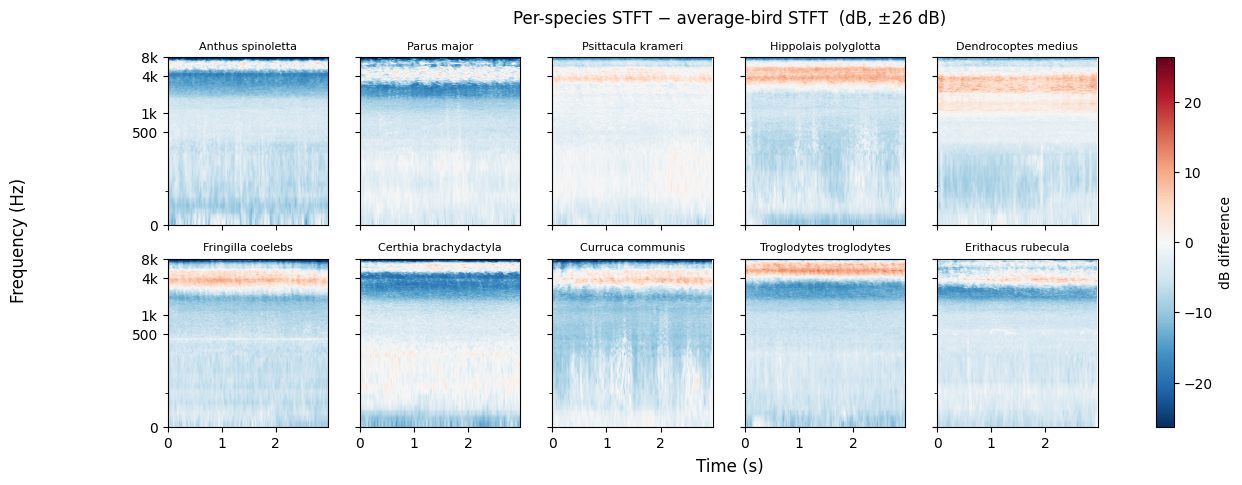

In [51]:
avg_o = cache["avg_other"]
ref_o = float(avg_o.max())
other_db = to_db(avg_o, ref=ref_o)

n = len(species)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 2.4 * rows), squeeze=False, sharex=True, sharey=True)
diffs = {}
for sp in species:
    mag = cache[f"species__{safe(sp)}"]
    sp_db = to_db(mag, ref=float(mag.max()))
    diffs[sp] = sp_db - other_db
vmax = max(np.percentile(np.abs(d), 98) for d in diffs.values())
for ax, sp in zip(axes.ravel(), species):
    im = ax.imshow(
        diffs[sp],
        origin="lower",
        aspect="auto",
        extent=[0, stft_times[-1], stft_freqs[0], stft_freqs[-1]],
        vmin=-vmax,
        vmax=vmax,
        cmap="RdBu_r",
    )
    ax.set_yscale("symlog", linthresh=200)
    ax.set_yticks([0, 500, 1000, 4000, 8000])
    ax.set_yticklabels(["0", "500", "1k", "4k", "8k"])
    ax.set_title(sp, fontsize=8)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.supxlabel("Time (s)")
fig.supylabel("Frequency (Hz)")
fig.suptitle("Per-species STFT − average-bird STFT  (dB, ±{:.0f} dB)".format(vmax))
fig.colorbar(im, ax=axes.ravel().tolist(), label="dB difference")
plt.show()

# Marginal frequency profile

Time-averaged spectrum per species, overlaid against the average bird. Quickly answers: "where in frequency does this species put its energy that other birds don't?"

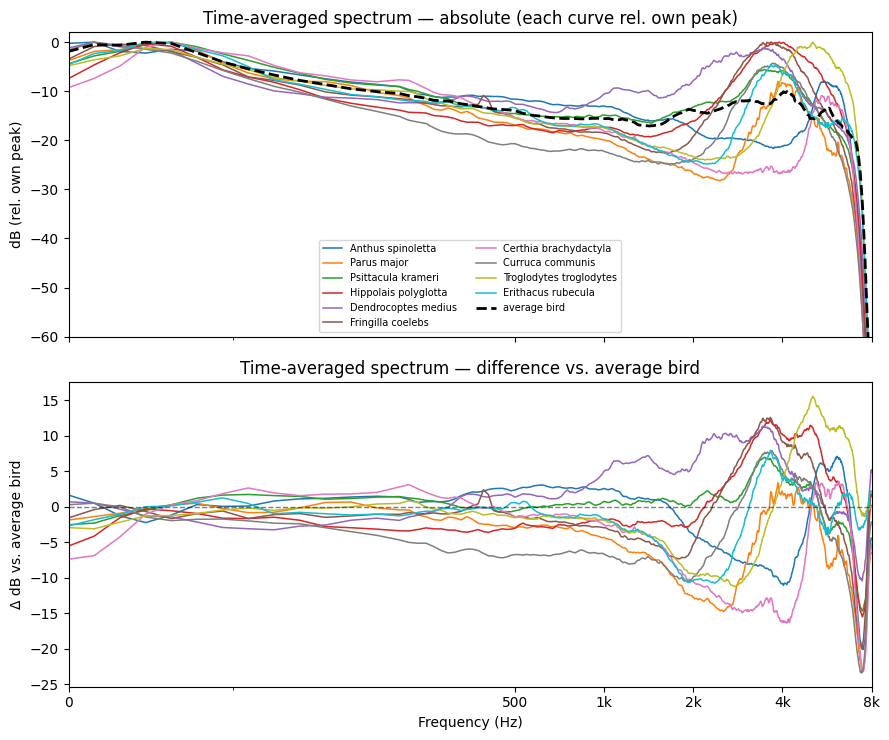

In [52]:
avg_o = cache["avg_other"]
other_profile = to_db(avg_o.mean(axis=1), ref=float(avg_o.mean(axis=1).max()))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 7.5), sharex=True)

# Absolute time-averaged spectrum, each curve dB-normalised to its own
# peak (so we compare shape, not loudness).
for sp in species:
    mag = cache[f"species__{safe(sp)}"]
    p = mag.mean(axis=1)
    p_db = to_db(p, ref=float(p.max()))
    ax_top.plot(stft_freqs, p_db, lw=1.1, label=sp)
ax_top.plot(stft_freqs, other_profile, color="k", lw=2, ls="--", label="average bird")
ax_top.set_ylabel("dB (rel. own peak)")
ax_top.set_ylim(-60, 2)
ax_top.legend(fontsize=7, ncol=2, loc="lower center")
ax_top.set_title("Time-averaged spectrum — absolute (each curve rel. own peak)")

# Difference vs. average bird. Positive = species louder than the
# average bird at that frequency, negative = quieter.
for sp in species:
    mag = cache[f"species__{safe(sp)}"]
    p = mag.mean(axis=1)
    p_db = to_db(p, ref=float(p.max()))
    ax_bot.plot(stft_freqs, p_db - other_profile, lw=1.1, label=sp)
ax_bot.axhline(0, color="k", lw=1, ls="--", alpha=0.5)
ax_bot.set_xlabel("Frequency (Hz)")
ax_bot.set_ylabel("Δ dB vs. average bird")
ax_bot.set_title("Time-averaged spectrum — difference vs. average bird")

for ax in (ax_top, ax_bot):
    ax.set_xscale("symlog", linthresh=200)
    ax.set_xticks([0, 500, 1000, 2000, 4000, 8000])
    ax.set_xticklabels(["0", "500", "1k", "2k", "4k", "8k"])
    ax.set_xlim(0, stft_freqs[-1])  # symlog pads into negatives by default
plt.tight_layout()
plt.show()

# Pre-split summary

Raw on-disk counts for target classes, AudioSet ambient pool, other-bird pool, and BirdNET no-bird clips — the four ingredients that go into `non_target` before train/val/test assembly.

In [ ]:
from building.data.dataset import AUDIOSET_DIR, BIRDNET_NO_BIRD_DIR, SUBSAMPLES_DIR


def _count(folder):
    return len(list(folder.glob("*.wav"))) if folder.exists() else 0


print("Target classes:")
for sp in info.target_species:
    print(f"  {sp}: {_count(SUBSAMPLES_DIR / sp.replace(' ', '_'))}")

as_total, as_classes = 0, 0
if AUDIOSET_DIR.exists():
    for d in sorted(AUDIOSET_DIR.iterdir()):
        if d.is_dir():
            n = _count(d)
            if n:
                as_total += n
                as_classes += 1
print(f"\nAudioSet: {as_total} clips across {as_classes} classes")

cap = info.budgets.non_target_per_species_cap
other_total, other_species_present, capped_total = 0, 0, 0
for sp in info.other_species:
    n = _count(SUBSAMPLES_DIR / sp.replace(" ", "_"))
    if n:
        other_total += n
        other_species_present += 1
        capped_total += min(n, cap)
print(
    f"\nOther birds: {other_total} clips on disk "
    f"across {other_species_present}/{len(info.other_species)} species"
)
print(
    f"After per-species cap ({cap}): "
    f"{capped_total} clips eligible for non_target xc_other pool"
)

print(f"\nBirdNET no-bird clips: {_count(BIRDNET_NO_BIRD_DIR)}")

# Per-source RMS distribution (pre-split)

Looking at raw clip levels before assembling the dataset so we can see the level imbalance per source. Bins of 2 dB from -70 to 0 dBFS, chosen from an empirical sample.

In [ ]:
from building.data.dataset import AUDIOSET_DIR, BIRDNET_NO_BIRD_DIR, SUBSAMPLES_DIR


def _rms_dbfs(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32)
    rms = np.sqrt(np.mean(x**2))
    return float(20.0 * np.log10(max(rms, 1e-10)))


def _scan(files: list) -> np.ndarray:
    out: list[float] = []
    for f in tqdm(files, desc=f"scan ({len(files)})", leave=False):
        try:
            x, _ = sf.read(str(f), dtype="float32", always_2d=False)
            if x.ndim > 1:
                x = x.mean(axis=-1)
            out.append(_rms_dbfs(x))
        except Exception:
            pass
    return np.array(out)


groups: list[tuple[str, np.ndarray]] = []

# One panel per target species.
for sp in info.target_species:
    folder = SUBSAMPLES_DIR / sp.replace(" ", "_")
    if folder.exists():
        groups.append((sp, _scan(sorted(folder.glob("*.wav")))))

# Other birds aggregated.
other_files: list = []
for sp in info.other_species:
    folder = SUBSAMPLES_DIR / sp.replace(" ", "_")
    if folder.exists():
        other_files.extend(folder.glob("*.wav"))
groups.append((f"Other birds ({len(info.other_species)} sp.)", _scan(other_files)))

# BirdNET no-bird clips.
if BIRDNET_NO_BIRD_DIR.exists():
    groups.append(
        ("BirdNET no-bird", _scan(sorted(BIRDNET_NO_BIRD_DIR.glob("*.wav"))))
    )

# AudioSet aggregated across focus classes.
if AUDIOSET_DIR.exists():
    as_files: list = []
    for d in sorted(AUDIOSET_DIR.iterdir()):
        if d.is_dir():
            as_files.extend(d.glob("*.wav"))
    groups.append(("AudioSet (all)", _scan(as_files)))

print(
    f"{'group':<32s} {'n':>5s}  {'q05':>6s} {'q50':>6s} {'q95':>6s}  "
    f"{'min':>6s} {'max':>6s}"
)
for label, a in groups:
    if len(a) == 0:
        continue
    print(
        f"{label:<32s} {len(a):>5d}  "
        f"{np.quantile(a, 0.05):>+6.1f} {np.median(a):>+6.1f} {np.quantile(a, 0.95):>+6.1f}  "
        f"{a.min():>+6.1f} {a.max():>+6.1f}"
    )

bins = np.arange(-70, 1, 2)
n = len(groups)
fig, axes = plt.subplots(n, 1, figsize=(10, max(2.0, 1.6 * n)), sharex=True)
if n == 1:
    axes = [axes]
for ax, (label, a) in zip(axes, groups):
    if len(a):
        ax.hist(a, bins=bins, color="steelblue", edgecolor="black", alpha=0.85)
        ax.axvline(
            np.median(a), color="red", lw=1, ls="--", label=f"median {np.median(a):+.1f}"
        )
        ax.legend(loc="upper left", fontsize=8, frameon=False)
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
axes[-1].set_xlabel("RMS (dBFS)")
fig.suptitle("Per-source RMS distribution (all data, pre-split)")
plt.tight_layout()
plt.show()